In [ ]:
# Imports and setup
import sys
from pathlib import Path
# Ensure the repository `src` folder is on sys.path so `from utils...` works when running cells
sys.path.append(str(Path('../../src').resolve()))

import warnings
import time
import traceback
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
import tensorflow as tf

# Configure a module-level logger used across the notebook
logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s %(message)s')
logger = logging.getLogger('nb004_run_all_models')

import optuna
from utils.models import MODELS, PARAM_GRIDS
from utils.eval_metrics import evaluate_model

# Use declarative variant definitions from utils.variants
from utils.variants import VARIANT_DEFS, apply_variant

warnings.filterwarnings('ignore')  # reduce clutter; remove if you want full warnings

In [2]:
BASE_DATA_PATH = Path('../../data/out/dataset_final.csv')

VARIANTS = [(v['name'], v) for v in VARIANT_DEFS]

# Quick check: print variant names and base data path existence
for vname, vdef in VARIANTS:
    print(vname, '-> base data exists?', BASE_DATA_PATH.exists())

# NOTE: data will be loaded per-variant inside the runner; apply_variant will be used to materialize each variant.

v7_only_gen_enso -> base data exists? True
v7_only_gen_enso_lags -> base data exists? True
v8_only_gen_no_solar_enso -> base data exists? True
v8_only_gen_no_solar_enso_lags -> base data exists? True
v9_date_range_all -> base data exists? True
v9_date_range_all_lags -> base data exists? True
v10_date_range_no_solar -> base data exists? True
v10_date_range_no_solar_lags -> base data exists? True


In [3]:
# Basic dataset settings (these are variant-agnostic constants)
TARGET_COLUMN = 'PRECIO'
# Columns that are categorical even if numeric - adjust if needed
categorical_numeric = ["YEAR", "MONTH", "DAY", "HORA", "NIVEL_ENSO", "DIA_SEMANA", "FESTIVO"]

# NOTE: Do not reference `df` at the top level. The dataset will be loaded per-variant inside
# the runner loop and `_prepare_variant_data(df, ...)` will build the preprocessor and perform
# the temporal train/test split for each variant separately.

print('Configured TARGET_COLUMN and categorical_numeric. Data will be loaded per-variant inside the runner.')

# If you need to inspect a single variant interactively, load it and call `_prepare_variant_data`:
# df_v, _ = apply_variant(pd.read_csv(BASE_DATA_PATH), VARIANT_DEFS[0], date_col='FECHA_HORA')
# preprocessor, X_train, X_test, y_train, y_test = _prepare_variant_data(df_v, target_column=TARGET_COLUMN, categorical_numeric=categorical_numeric)


Configured TARGET_COLUMN and categorical_numeric. Data will be loaded per-variant inside the runner.


In [4]:
# Runner function: fits (Optuna for boosting models / GridSearch for others) and evaluates a model
BOOSTING_NAMES = {"XGBoost", "LightGBM", "CatBoost"}

def _is_all_int(lst):
    try:
        return all(float(x).is_integer() for x in lst)
    except Exception:
        return False


def _convert_grid_to_optuna_suggestions(trial, param_grid):
    """Given a param_grid dict (name -> list of candidate values), use heuristics
    to call appropriate trial.suggest_* methods and return a params dict.

    Heuristics:
    - If all values are ints -> suggest_int(min, max)
    - If values are numeric (floats/ints) and not all ints -> suggest_float(min, max, log=True)
    - Otherwise -> suggest_categorical
    """
    params = {}
    for p, choices in param_grid.items():
        # Ensure choices is list-like
        try:
            choices_list = list(choices)
        except Exception:
            # fallback to categorical
            params[p] = trial.suggest_categorical(p, choices)
            continue

        # If only two values and they are numeric, use suggest_int/float between them
        if len(choices_list) >= 2 and all(isinstance(v, (int, float)) for v in choices_list):
            mins = min(choices_list)
            maxs = max(choices_list)
            if _is_all_int(choices_list):
                params[p] = trial.suggest_int(p, int(mins), int(maxs))
            else:
                # Use log-scale for learning rates etc when range spans several orders
                try:
                    params[p] = trial.suggest_float(p, float(mins), float(maxs), log=True)
                except Exception:
                    params[p] = trial.suggest_float(p, float(mins), float(maxs))
        else:
            # fallback to categorical
            params[p] = trial.suggest_categorical(p, choices_list)

    return params

def _prepare_variant_data(df, target_column= 'PRECIO', categorical_numeric=None):
    """Given a dataframe, prepare X/y and preprocessor based on default rules used above.

    Returns: preprocessor, X_train, X_test, y_train, y_test
    """
    if categorical_numeric is None:
        categorical_numeric = ["YEAR", "MONTH", "DAY", "HORA", "NIVEL_ENSO", "DIA_SEMANA", "FESTIVO"]

    numeric_features = [col for col in df.columns if col not in categorical_numeric and col != target_column and col != 'FECHA_HORA']
    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), numeric_features),
        ('cat', 'passthrough', [c for c in categorical_numeric if c in df.columns])
    ])

    X = df.drop(columns=['FECHA_HORA', target_column], errors='ignore')
    y = df[target_column]

    train_size = int(len(df) * 0.8)
    X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
    y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

    return preprocessor, X_train, X_test, y_train, y_test


def run_model(name, estimator, param_grid=None, *, variant='no_lags', df=None, n_trials=30):
    """Run a single model for a specific data variant (no_lags / with_lags).

    - variant: string tag used in results
    - df: the dataframe to use for this run (if None, function will error)

    Returns a dict with the result and the variant included.
    """
    if df is None:
        raise ValueError('df must be provided for run_model when running by variant')

    preprocessor_local, X_train_v, X_test_v, y_train_v, y_test_v = _prepare_variant_data(df)

    result = {'model': name, 'variant': variant}
    start_time = time.time()

    if estimator is None:
        result.update({'status': 'unavailable'})
        return result

    # Build pipeline with local preprocessor (per-variant)
    pipe = Pipeline([('preprocessor', preprocessor_local), ('model', estimator)])

    try:
        # Use Optuna for boosting libraries if grid provided
        if param_grid is not None and len(param_grid) > 0 and name in BOOSTING_NAMES:
            logger.info(f'Running Optuna for {name} (n_trials={n_trials}) on variant {variant}...')

            def objective(trial):
                params = _convert_grid_to_optuna_suggestions(trial, param_grid)
                ModelClass = type(estimator)
                model = ModelClass(**params)
                tscv = TimeSeriesSplit(n_splits=3)
                scores = cross_val_score(model, X_train_v, y_train_v, cv=tscv, scoring='neg_root_mean_squared_error', n_jobs=-1)
                return -scores.mean()

            study = optuna.create_study(direction='minimize')
            study.optimize(objective, n_trials=n_trials)

            best_params = study.best_trial.params
            result['status'] = 'optuna_done'
            result['best_params'] = best_params

            # Fit final model with best params
            ModelClass = type(estimator)
            final_model = ModelClass(**best_params)
            final_pipe = Pipeline([('preprocessor', preprocessor_local), ('model', final_model)])
            final_pipe.fit(X_train_v, y_train_v)

            metrics = evaluate_model(final_pipe, X_test_v, y_test_v)
            result.update(metrics)

        elif param_grid is not None and len(param_grid) > 0:
            # GridSearch for non-boosting models
            logger.info(f'Running GridSearchCV for {name} on variant {variant}...')
            grid_prefixed = {f'model__{k}': v for k, v in param_grid.items()}
            tscv = TimeSeriesSplit(n_splits=3)
            gs = GridSearchCV(pipe, grid_prefixed, cv=tscv, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=0)
            gs.fit(X_train_v, y_train_v)
            best = gs.best_estimator_
            result['status'] = 'grid_search_done'
            result['best_params'] = {k.replace('model__', ''): v for k, v in gs.best_params_.items()}
            result['best_neg_rmse'] = float(gs.best_score_)
            metrics = evaluate_model(best, X_test_v, y_test_v)
            result.update(metrics)

        else:
            # No grid: train and evaluate
            logger.info(f'Training {name} (no grid) on variant {variant}...')
            pipe.fit(X_train_v, y_train_v)
            result['status'] = 'trained'
            result['best_params'] = None
            metrics = evaluate_model(pipe, X_test_v, y_test_v)
            result.update(metrics)

    except Exception as e:
        # Robust error handling: capture traceback and include in results
        tb = traceback.format_exc()
        logger.error(f'Error training {name} on variant {variant}: {e}\n{tb}')
        result['status'] = 'error'
        result['error'] = str(e)
        result['traceback'] = tb

    finally:
        elapsed = time.time() - start_time
        
        result['n_total'] = len(y_train_v) + len(y_test_v)
        result['n_train'] = len(y_train_v)
        result['n_test'] = len(y_test_v)
        result['train_time_s'] = elapsed

    return result

In [5]:
# Iterate over variants and models, run them and collect results (per-variant folders)
all_results = []
variant_summaries = {}

# We will load the base dataset per-variant so apply_variant can materialize the specific view
# (e.g., drop columns, create lags). This avoids referencing a top-level `df` and ensures
# each variant is processed independently.

for vname, vdef in VARIANTS:
    
    print(f'Processing variant: {vname}')
    # create per-variant output folder
    variant_out = Path('../../data/out/variants') / vname
    variant_out.mkdir(parents=True, exist_ok=True)

    # Load base dataset for this variant
    BASE_DF = pd.read_csv(BASE_DATA_PATH)

    # apply variant transformations and save a CSV snapshot
    try:
        df_v, vmeta = apply_variant(BASE_DF, vdef, date_col='FECHA_HORA', holiday_years=list(range(2020,2026)), save_csv=variant_out / f'dataset_{vname}.csv')
    except Exception as e:
        logger.exception(f'Error applying variant {vname}: {e}')
        continue

    # register metadata in results
    vmeta_row = {**vmeta}

    variant_results = []
    for name, estimator in tqdm(MODELS.items(), desc=f'Models ({vname})', unit='model'):
        grid = PARAM_GRIDS.get(name)
        try:
            res = run_model(name, estimator, grid, variant=vname, df=df_v, n_trials=30)
        except Exception as e:
            logger.exception(f'Unhandled error running {name} on variant {vname}')
            res = {'model': name, 'variant': vname, 'status': 'error', 'error': str(e)}
        logger.info(f'Result for {name} (variant={vname}): {res.get("status")}')
        # attach variant metadata to each result
        res['_variant_meta'] = vmeta_row
        variant_results.append(res)
        all_results.append(res)

    # Consolidate per-variant summary
    variant_df = pd.DataFrame(variant_results).set_index('model')
    variant_summaries[vname] = variant_df
    # save per-variant raw + summary
    try:
        variant_df.to_excel(variant_out / f'summary_{vname}.xlsx')
        pd.DataFrame(variant_results).to_excel(variant_out / f'raw_{vname}.xlsx')
    except Exception as e:
        logger.warning(f'Could not save per-variant excel for {vname}: {e}')

# Global consolidation
results_df = pd.DataFrame(all_results).set_index(['variant','model'])

# Determine best model per variant by RMSE (lower is better)
best_per_variant = {}
for vname, vdf in variant_summaries.items():
    try:
        if 'RMSE' in vdf.columns:
            valid = vdf[~vdf['RMSE'].isna()]
            if len(valid) > 0:
                best_idx = valid['RMSE'].astype(float).idxmin()
                best_per_variant[vname] = vdf.loc[[best_idx]]
    except Exception as e:
        logger.warning(f'Could not determine best model for variant {vname}: {e}')

# Global best across all variants (by RMSE)
global_best = None
try:
    if 'RMSE' in results_df.columns:
        valid_all = results_df[~results_df['RMSE'].isna()]
        if len(valid_all) > 0:
            global_best_idx = valid_all['RMSE'].astype(float).idxmin()
            global_best = results_df.loc[[global_best_idx]]
except Exception as e:
    logger.warning(f'Could not determine global best model: {e}')

# Save consolidated results to Excel: a sheet per-variant and global summary/raw
out_dir = Path('../../data/out')
out_dir.mkdir(parents=True, exist_ok=True)
out_file = out_dir / 'all_models_results.xlsx'
with pd.ExcelWriter(out_file, engine='openpyxl') as writer:
    # summary sheets per variant
    for vname, vdf in variant_summaries.items():
        vdf.to_excel(writer, sheet_name=f'summary_{vname}')
        pd.DataFrame([r for r in all_results if r.get('variant')==vname]).to_excel(writer, sheet_name=f'raw_{vname}')

    # global combined summary and raw
    try:
        results_df.reset_index().to_excel(writer, sheet_name='summary_global', index=False)
    except Exception:
        pd.DataFrame(all_results).to_excel(writer, sheet_name='summary_global')
    pd.DataFrame(all_results).to_excel(writer, sheet_name='raw_all')

    # best per variant
    for vname, bdf in best_per_variant.items():
        bdf.to_excel(writer, sheet_name=f'best_{vname}')

    # global best
    if global_best is not None:
        global_best.to_excel(writer, sheet_name='best_global')

logger.info(f'Saved consolidated results to {out_file}')
print(f'Saved consolidated results to {out_file}')


Processing variant: v7_only_gen_enso


Models (v7_only_gen_enso):   0%|          | 0/15 [00:00<?, ?model/s]

2025-10-12 00:26:38,959 INFO Training Linear Regression (no grid) on variant v7_only_gen_enso...
2025-10-12 00:26:38,989 INFO Result for Linear Regression (variant=v7_only_gen_enso): trained
2025-10-12 00:26:38,997 INFO Training Ridge (no grid) on variant v7_only_gen_enso...
2025-10-12 00:26:39,020 INFO Result for Ridge (variant=v7_only_gen_enso): trained
2025-10-12 00:26:39,023 INFO Training Lasso (no grid) on variant v7_only_gen_enso...
2025-10-12 00:26:39,079 INFO Result for Lasso (variant=v7_only_gen_enso): trained
2025-10-12 00:26:39,082 INFO Running GridSearchCV for ElasticNet on variant v7_only_gen_enso...
2025-10-12 00:26:43,115 INFO Result for ElasticNet (variant=v7_only_gen_enso): grid_search_done
2025-10-12 00:26:43,115 INFO Running GridSearchCV for Decision Tree on variant v7_only_gen_enso...
2025-10-12 00:26:44,427 INFO Result for Decision Tree (variant=v7_only_gen_enso): grid_search_done
2025-10-12 00:26:44,438 INFO Running GridSearchCV for Random Forest on variant v7_onl

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000538 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1282
[LightGBM] [Info] Number of data points in the train set: 38553, number of used features: 6
[LightGBM] [Info] Start training from score 318.239462


2025-10-12 00:38:28,303 INFO Result for LightGBM (variant=v7_only_gen_enso): optuna_done
2025-10-12 00:38:28,317 INFO Running Optuna for CatBoost (n_trials=30) on variant v7_only_gen_enso...
[I 2025-10-12 00:38:28,319] A new study created in memory with name: no-name-680a265b-a960-4f3b-b51b-3454ff61d8a5
[I 2025-10-12 00:38:32,092] Trial 0 finished with value: 180.80578184344998 and parameters: {'iterations': 471, 'learning_rate': 0.08653611435437349, 'depth': 7}. Best is trial 0 with value: 180.80578184344998.
[I 2025-10-12 00:38:34,680] Trial 1 finished with value: 173.0613887627619 and parameters: {'iterations': 468, 'learning_rate': 0.062481457888882416, 'depth': 5}. Best is trial 1 with value: 173.0613887627619.
[I 2025-10-12 00:38:36,288] Trial 2 finished with value: 174.48190286274698 and parameters: {'iterations': 225, 'learning_rate': 0.07476187771868793, 'depth': 5}. Best is trial 1 with value: 173.0613887627619.
[I 2025-10-12 00:38:41,866] Trial 3 finished with value: 184.409

...

0:	learn: 440.5530809	total: 5.47ms	remaining: 3.45s
1:	learn: 433.1636259	total: 10.9ms	remaining: 3.44s
2:	learn: 425.8588113	total: 14.9ms	remaining: 3.12s
3:	learn: 419.1284520	total: 19.1ms	remaining: 3s
4:	learn: 412.6524987	total: 23ms	remaining: 2.88s
5:	learn: 406.1112634	total: 26.8ms	remaining: 2.79s
6:	learn: 399.5333728	total: 30.6ms	remaining: 2.73s
7:	learn: 393.1733794	total: 34.3ms	remaining: 2.67s
8:	learn: 386.7149447	total: 37.8ms	remaining: 2.62s
9:	learn: 380.4358621	total: 41.6ms	remaining: 2.58s
10:	learn: 374.2304897	total: 45.1ms	remaining: 2.55s
11:	learn: 368.4229520	total: 48.5ms	remaining: 2.5s
12:	learn: 362.4315203	total: 51.8ms	remaining: 2.47s
13:	learn: 356.8204800	total: 55.4ms	remaining: 2.45s
14:	learn: 351.4787857	total: 59.1ms	remaining: 2.43s
15:	learn: 345.8509514	total: 62.7ms	remaining: 2.41s
16:	learn: 340.2387042	total: 66.3ms	remaining: 2.4s
17:	learn: 334.9845166	total: 70ms	remaining: 2.39s
18:	learn: 330.0602933	total: 73.4ms	remaining:

2025-10-12 06:17:59,829 INFO Result for CatBoost (variant=v10_date_range_no_solar_lags): optuna_done
2025-10-12 06:17:59,837 INFO Running GridSearchCV for Extra Trees on variant v10_date_range_no_solar_lags...


622:	learn: 86.8255688	total: 3.3s	remaining: 47.7ms
623:	learn: 86.8093275	total: 3.31s	remaining: 42.4ms
624:	learn: 86.7889124	total: 3.31s	remaining: 37.1ms
625:	learn: 86.7660571	total: 3.32s	remaining: 31.8ms
626:	learn: 86.7235153	total: 3.33s	remaining: 26.5ms
627:	learn: 86.6935180	total: 3.33s	remaining: 21.2ms
628:	learn: 86.6759346	total: 3.34s	remaining: 15.9ms
629:	learn: 86.6385287	total: 3.35s	remaining: 10.6ms
630:	learn: 86.6006055	total: 3.35s	remaining: 5.32ms
631:	learn: 86.5825107	total: 3.36s	remaining: 0us


2025-10-12 06:20:22,924 INFO Result for Extra Trees (variant=v10_date_range_no_solar_lags): grid_search_done
2025-10-12 06:20:22,931 INFO Running GridSearchCV for HistGradientBoosting on variant v10_date_range_no_solar_lags...
2025-10-12 06:21:01,898 INFO Result for HistGradientBoosting (variant=v10_date_range_no_solar_lags): grid_search_done
2025-10-12 06:21:01,903 INFO Running GridSearchCV for MLP Regressor on variant v10_date_range_no_solar_lags...
2025-10-12 06:28:58,824 INFO Result for MLP Regressor (variant=v10_date_range_no_solar_lags): grid_search_done
2025-10-12 06:28:59,755 INFO Saved consolidated results to ..\..\data\out\all_models_results.xlsx


Saved consolidated results to ..\..\data\out\all_models_results.xlsx


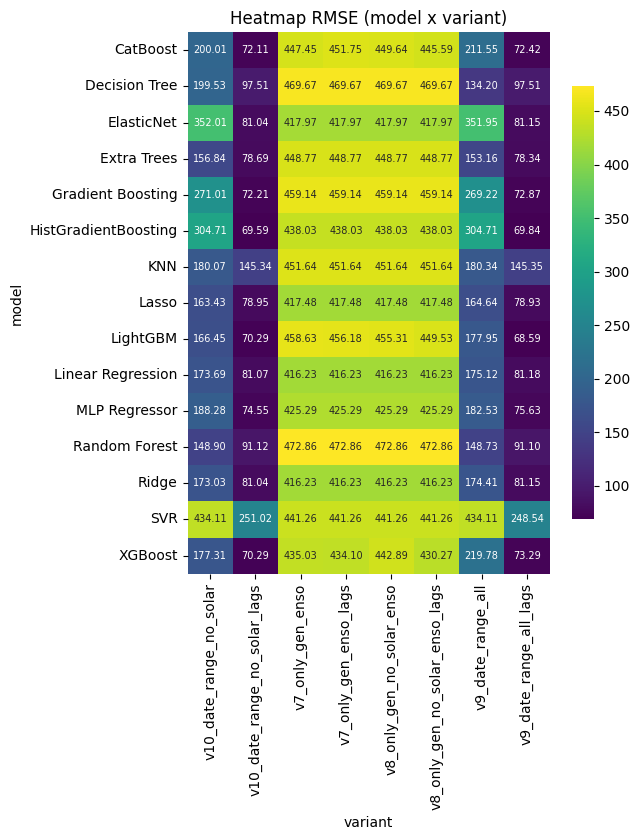

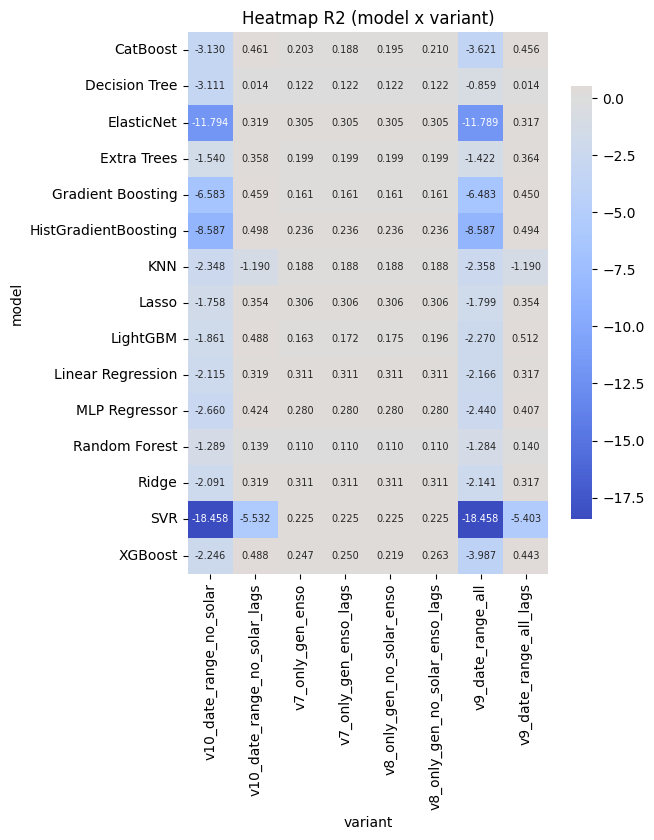

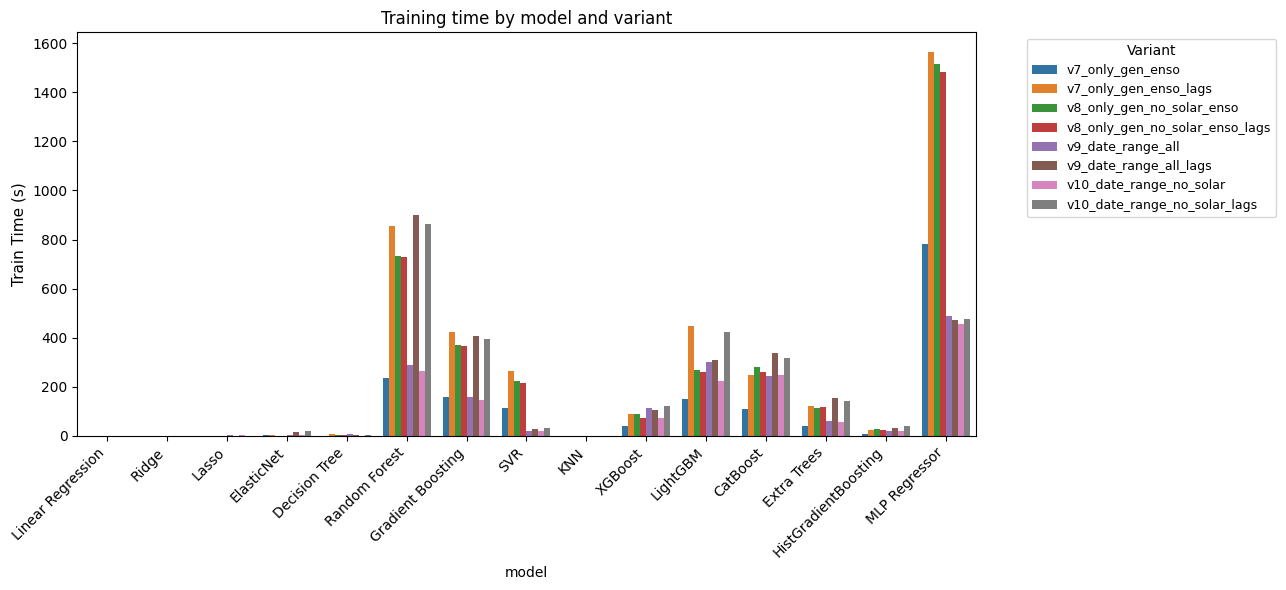

In [6]:
# Build a plotting dataframe from results
try:
    plot_df = results_df.reset_index()
except Exception:
    plot_df = pd.DataFrame(all_results)

plot_df = plot_df.copy()
# ensure numeric types
for col in ['RMSE', 'R2', 'train_time_s']:
    if col in plot_df.columns:
        plot_df[col] = pd.to_numeric(plot_df[col], errors='coerce')

# Pivot tables for RMSE and R2 (models x variants)
if 'RMSE' in plot_df.columns:
    pivot_rmse = plot_df.pivot_table(index='model', columns='variant', values='RMSE')
else:
    pivot_rmse = pd.DataFrame()

if 'R2' in plot_df.columns:
    pivot_r2 = plot_df.pivot_table(index='model', columns='variant', values='R2')
else:
    pivot_r2 = pd.DataFrame()

out_dir = Path('../../data/out/result_plots')
out_dir.mkdir(parents=True, exist_ok=True)

# ------- GRAPH 1A: HEATMAP RMSE --------
if not pivot_rmse.empty:
    fig_width = min(12, 1 + 0.7 * pivot_rmse.shape[1])
    fig_height = min(10, 1 + 0.5 * pivot_rmse.shape[0])

    plt.figure(figsize=(fig_width, fig_height))
    sns.heatmap(
        pivot_rmse,
        annot=True,
        fmt='.2f',
        cmap='viridis',
        annot_kws={"size": 7},
        cbar_kws={"shrink": 0.8}
    )
    plt.title('Heatmap RMSE (model x variant)')
    plt.tight_layout()
    plt.savefig(out_dir / 'rmse_heatmap.png')
    plt.show()


# ------- GRAPH 1B: HEATMAP R2 --------
if not pivot_r2.empty:
    fig_width = min(12, 1 + 0.7 * pivot_r2.shape[1])
    fig_height = min(10, 1 + 0.5 * pivot_r2.shape[0])

    plt.figure(figsize=(fig_width, fig_height))
    sns.heatmap(
        pivot_r2,
        annot=True,
        fmt='.3f',
        cmap='coolwarm',
        center=0,
        annot_kws={"size": 7},  # fuente más legible
        cbar_kws={"shrink": 0.8}
    )
    plt.title('Heatmap R2 (model x variant)')
    plt.tight_layout()
    plt.savefig(out_dir / 'r2_heatmap.png')
    plt.show()



# ------- GRAPH 2: TRAIN TIME --------
if 'train_time_s' in plot_df.columns and not plot_df['train_time_s'].isna().all():
    tt = plot_df.dropna(subset=['train_time_s'])

    model_count = tt['model'].nunique()
    fig_width = min(14, 1 + 0.8 * model_count)

    plt.figure(figsize=(fig_width, 6))
    ax = sns.barplot(data=tt, x='model', y='train_time_s', hue='variant', dodge=True)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(fontsize=10)
    plt.ylabel('Train Time (s)', fontsize=11)
    plt.title('Training time by model and variant', fontsize=12)
    plt.legend(title='Variant', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, title_fontsize=10)
    plt.tight_layout()
    plt.savefig(out_dir / 'train_time_by_model_variant.png')
    plt.show()

